In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch
from collections import Counter
import numpy as np
from matplotlib import cm
from matplotlib import colors
import seaborn as sns


In [3]:
r = pd.read_excel(r'Results_3.xlsx')
display(r.head(5))

#s = pd.read_excel('Sprint_3.xlsx')
#display(s.head(3))

#t = pd.read_excel('Testing.xlsx')
#display(t.head(3))

,resultId,raceId,year,driverId,driverRef,00_Drivers_number,constructorId,00_Results_number,grid,position,positionText,positionOrder,points,laps,Time,fastestLap,rank,statusId,status,driverCode
0,46,20,2008,8,raikkonen,7,6,1,4,2,2,2,8.0,57,3.339,35,4,1,Finished,Rai
1,47,20,2008,9,kubica,88,2,4,1,3,3,3,6.0,57,4.998,55,5,1,Finished,Kub
2,48,20,2008,2,heidfeld,\N,2,3,6,4,4,4,5.0,57,8.409,48,2,1,Finished,Hei
3,49,20,2008,5,kovalainen,\N,1,23,5,5,5,5,4.0,57,26.789,49,1,1,Finished,Kov
4,50,20,2008,15,trulli,\N,7,11,7,6,6,6,3.0,57,41.314,45,7,1,Finished,Tru


**Figure 1: Formula One Career Results**

In [4]:

edge_list = []

for race_id, df in r.groupby("raceId"):
    df = df.sort_values("position")

    for i in range(len(df) - 1):
        a = df.iloc[i]["driverId"]
        b = df.iloc[i + 1]["driverId"]

        if a != b:
            edge_list.append((a, b))


edge_counts = Counter(edge_list)

G = nx.DiGraph()

for (u, v), w in edge_counts.items():
    G.add_edge(u, v, weight=w)

G.remove_edges_from(nx.selfloop_edges(G))

In [5]:
race_year = (
    r.drop_duplicates("raceId")
     .set_index("raceId")["year"]
)

r["race_year"] = r["raceId"].map(race_year)

first_year = r.groupby("driverId")["race_year"].min()

nodes = list(G.nodes())

global_min_year = first_year.min()

years = np.array([first_year.get(n, global_min_year) for n in nodes])
year_min, year_max = years.min(), years.max()

Sorting nodes based on their debut year

In [6]:

cmap = plt.cm.viridis
norm = plt.Normalize(year_min, year_max)

node_colors = [
    cmap(norm(first_year.get(n, year_min)))
    for n in nodes
]


sorted_nodes = sorted(nodes, key=lambda n: first_year.get(n, year_min))
n = len(sorted_nodes)

gap = np.pi / 6  

start_angle = gap / 2
end_angle = 2 * np.pi - gap / 2

angles = np.linspace(start_angle, end_angle, n)

base_radius = 5

pos = {}

for i, (node, angle) in enumerate(zip(sorted_nodes, angles)):
    
    
    radius_noise = np.random.normal(scale=1.2)
    angle_noise = np.random.normal(scale=0.015)
    wave = np.sin(i / n * 3 * np.pi) * 1.2
    
    rad = base_radius + radius_noise + wave   
    a = angle + angle_noise

    x = rad * np.cos(a)
    y = rad * np.sin(a)

    y *= 1.2

    pos[node] = (x, y)




In [7]:
driver_points = r.groupby("driverId")["points"].sum()

node_sizes = np.array([
    np.log1p(driver_points.get(n, 0)) * 50 + 10
    for n in nodes
])


weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
max_w = weights.max() if len(weights) > 0 else 1

weights_norm = 0.5 + (weights / max_w) * 2.5


driver_code_map = (
    r.drop_duplicates("driverId")
     .set_index("driverId")["driverCode"]
     .to_dict()
)

top_n = 40

top_nodes = sorted(
    nodes,
    key=lambda n: driver_points.get(n, 0),
    reverse=True
)[:top_n]



Assigning node sizes based on total career points.
Weights are determined by how often one driver beats another

The Top 40 point scoreres are labeled by driver code (first 3 letters of their last name)

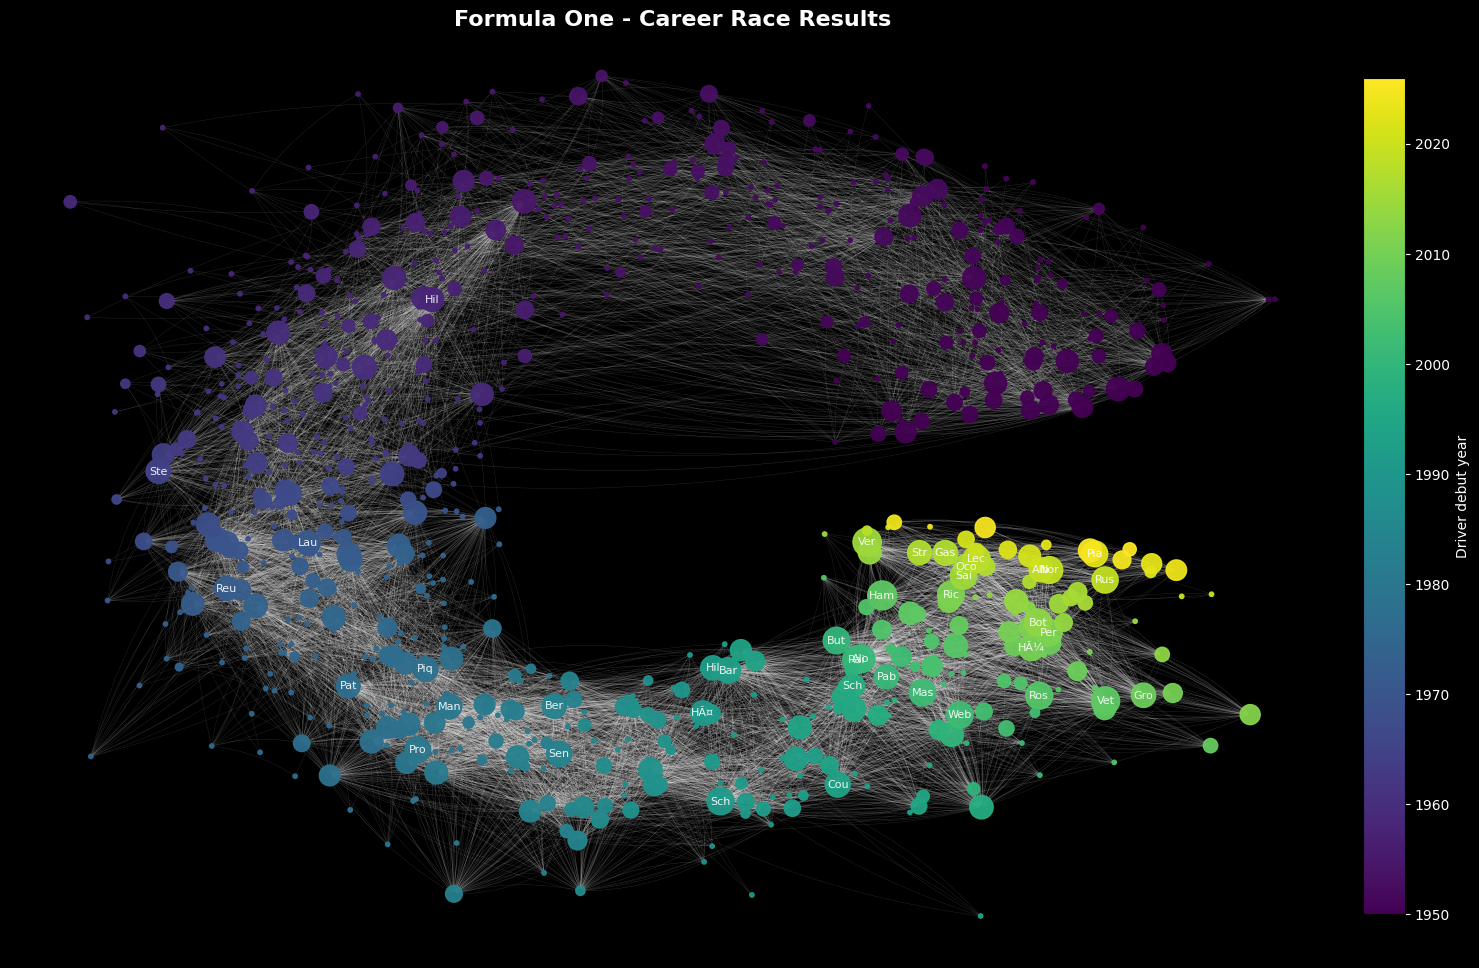

In [8]:

plt.figure(figsize=(18, 12))
ax = plt.gca()

ax.set_facecolor("black")
plt.gcf().set_facecolor("black")


for (u, v), w in zip(G.edges(), weights_norm):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        connectionstyle="arc3,rad=0.12",
        arrowstyle='-',
        linewidth=w * 0.4,
        color="white",
        alpha=0.2
    )
    ax.add_patch(arrow)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.95
)

for n in top_nodes:
    x, y = pos[n]
    label = driver_code_map.get(n, str(n))

    plt.text(
        x,
        y,
        label,
        fontsize=8,
        color="white",
        ha="center",
        va="center",
        alpha=0.9
    )


plt.title(
    "Formula One - Career Race Results",
    color="white",
    fontweight = 'bold',
    fontsize=16
)


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  

cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Driver debut year", color="white")


cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')


plt.axis("off")
plt.show()

Each node is representative of a driver’s initial debut, with earliest being represented in purple and latest in yellow. The edges depict race results of each driver; the connection is linked to the driver that finished in the position directly behind them (ex. Driver 1 finished 1st -> Driver 2 finished 2nd). Additionally, nodes are clustered based on common links, so if Driver 1 and Driver 2 finish next to each other often, they will be depicted closer on the graph, this explains the nodes that tend to float far away from the central graph. These nodes are Drivers that are not finishing next to any common drivers and usually have few links indicating there may be inconsistent or poor performance. Node size is determined by a driver’s total career points, so drivers that have had more successful careers will be larger

**Figure 2: Top 40 Drivers With Longest Careers**

In [9]:

edge_list = []

for race_id, df in r.groupby("raceId"):
    df = df.sort_values("position")

    for i in range(len(df) - 1):
        a = df.iloc[i]["driverId"]
        b = df.iloc[i + 1]["driverId"]

        if a != b:
            edge_list.append((a, b))


edge_counts = Counter(edge_list)

G = nx.DiGraph()

for (u, v), w in edge_counts.items():
    G.add_edge(u, v, weight=w)

G.remove_edges_from(nx.selfloop_edges(G))

In [10]:
race_year = (
    r.drop_duplicates("raceId")
     .set_index("raceId")["year"]
)

r["race_year"] = r["raceId"].map(race_year)

first_year = r.groupby("driverId")["race_year"].min()



year_min = first_year.min()
year_max = first_year.max()

norm = plt.Normalize(vmin=year_min, vmax=year_max)
cmap = cm.viridis


nodes = list(G.nodes())

years = np.array([first_year.get(n, year_min) for n in nodes])

node_colors = [
    cmap(norm(first_year.get(n, year_min))) if n in top_nodes else "gray"
    for n in nodes
]


sorted_nodes = sorted(nodes, key=lambda n: first_year.get(n, year_min))
n = len(sorted_nodes)

Determines the color of nodes, 1950s -> dark purple, 2025 -> yellow

In [11]:
gap = np.pi / 6  

start_angle = gap / 2
end_angle = 2 * np.pi - gap / 2

angles = np.linspace(start_angle, end_angle, n)

base_radius = 5

pos = {}

for i, (node, angle) in enumerate(zip(sorted_nodes, angles)):
    
    
    radius_noise = np.random.normal(scale=1.2)
    angle_noise = np.random.normal(scale=0.015)
    wave = np.sin(i / n * 3 * np.pi) * 1.2
    
    rad = base_radius + radius_noise + wave   
    a = angle + angle_noise

    x = rad * np.cos(a)
    y = rad * np.sin(a)

    y *= 1.2

    pos[node] = (x, y)




In [12]:

driver_points = r.groupby("driverId")["points"].sum()

node_sizes = np.array([
    np.log1p(driver_points.get(n, 0)) * 50 + 10
    for n in nodes
])


weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
max_w = weights.max() if len(weights) > 0 else 1

weights_norm = 0.5 + (weights / max_w) * 2.5

Node sizes determined by career points, weights are determined by how often a driver (Driver 1) beats another (Driver 2)

In [13]:

driver_code_map = (
    r.drop_duplicates("driverId")
     .set_index("driverId")["driverCode"]
     .to_dict()
)


career_span = r.groupby("driverId")["race_year"].agg(["min", "max"])
career_span["span"] = career_span["max"] - career_span["min"]

top_n = 40

top_nodes = career_span.sort_values("span", ascending=False).head(top_n).index.tolist()


top_40_df = career_span.sort_values("span", ascending=False).head(40).copy()

top_40_df["driverCode"] = top_40_df.index.map(driver_code_map)

top_40_df = top_40_df.reset_index().rename(columns={"index": "driverId"})

print(top_40_df[["driverId", "driverCode", "min", "max", "span"]])



    driverId driverCode   min   max  span
0          4        Alo  2001  2026    25
1         30        Sch  1991  2012    21
2          8        Rai  2001  2021    20
3          1        Ham  2007  2026    19
4         22        Bar  1993  2011    18
5         18        But  2000  2017    17
6        289        Hil  1958  1975    17
7        807        HÃ¼  2010  2026    16
8         69        Bad  1993  2009    16
9        119        Pat  1977  1993    16
10       356        Bra  1955  1970    15
11         9        Kub  2006  2021    15
12       815        Per  2011  2026    15
13       347        Bon  1956  1971    15
14        13        Mas  2002  2017    15
15        95        Man  1980  1995    15
16        20        Vet  2007  2022    15
17       427        Tri  1950  1964    14
18       110         de  1980  1994    14
19        15        Tru  1997  2011    14
20        14        Cou  1994  2008    14
21       182        Lau  1971  1985    14
22       207        And  1968  198

Selects the top 40 drivers based on career length (span)

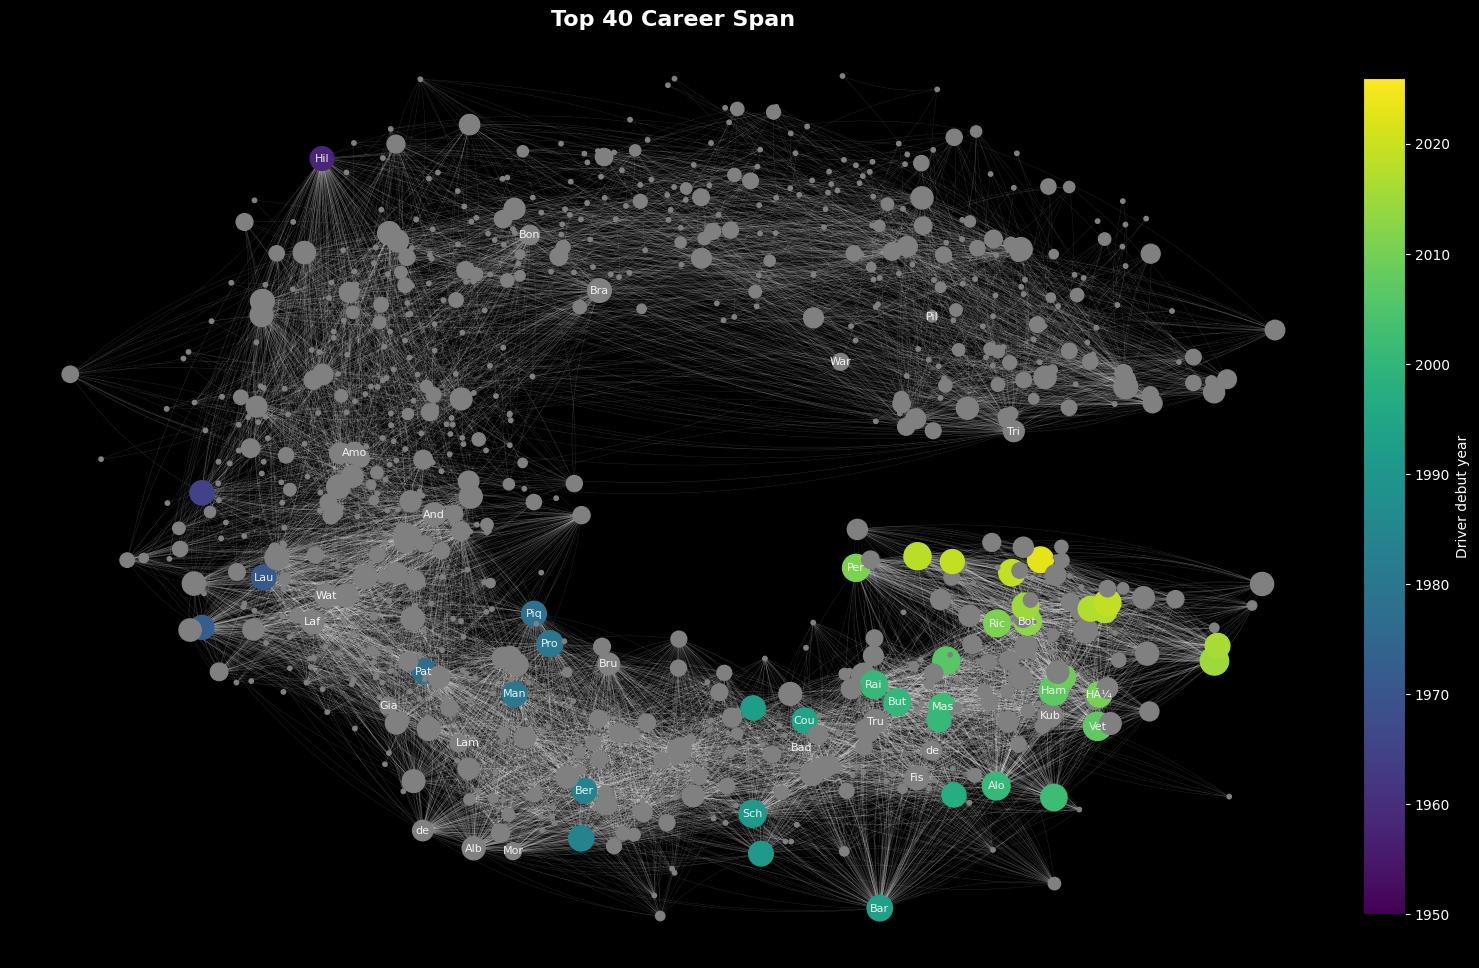

In [14]:
plt.figure(figsize=(18, 12))
ax = plt.gca()
ax.set_facecolor("black")
plt.gcf().set_facecolor("black")
for (u, v), w in zip(G.edges(), weights_norm):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        connectionstyle="arc3,rad=0.12",
        arrowstyle='-',
        linewidth=w * 0.4,
        color="white",
        alpha=0.2
    )
    ax.add_patch(arrow)
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=1.0
)
for n in top_nodes:
    x, y = pos[n]
    label = driver_code_map.get(n, str(n))
    plt.text(
        x,
        y,
        label,
        fontsize=8,
        color="white",
        ha="center",
        va="center",
        alpha=0.9
    )
plt.title(
    "Top 40 Career Span",
    color="white",
    fontweight='bold',
    fontsize=16
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  

cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Driver debut year", color="white")


cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.axis("off")
plt.show()

**Figure 3: Top 40 Drivers with Longest Link**

In [15]:
cmap = plt.cm.viridis
norm = plt.Normalize(year_min, year_max)

edge_list = []

for race_id, df in r.groupby("raceId"):
    df = df.sort_values("position")

    for i in range(len(df) - 1):
        a = df.iloc[i]["driverId"]
        b = df.iloc[i + 1]["driverId"]

        if a != b:
            edge_list.append((a, b))


edge_counts = Counter(edge_list)

G = nx.DiGraph()

for (u, v), w in edge_counts.items():
    G.add_edge(u, v, weight=w)

G.remove_edges_from(nx.selfloop_edges(G))

In [16]:
race_year = (
    r.drop_duplicates("raceId")
     .set_index("raceId")["year"]
)

r["race_year"] = r["raceId"].map(race_year)

first_year = r.groupby("driverId")["race_year"].min()
print(first_year.unique())


nodes = list(G.nodes())

year_min = first_year.min()
year_max = first_year.max()

norm = plt.Normalize(vmin=year_min, vmax=year_max)
cmap = cm.viridis


years = np.array([first_year.get(n, year_min) for n in nodes])


driver_code_map = (
    r.drop_duplicates("driverId")
     .set_index("driverId")["driverCode"]
     .to_dict()
)


career_span = r.groupby("driverId")["race_year"].agg(["min", "max"])
career_span["span"] = career_span["max"] - career_span["min"]

top_n = 40
top_nodes = career_span.sort_values("span", ascending=False).head(top_n).index.tolist()


node_colors = [
    cmap(norm(first_year.get(n, year_min))) if n in top_nodes else "gray"
    for n in nodes
]

[2007 2000 2006 2001 2008 2004 2002 1994 1997 1996 1993 2005 1991 1999
 2003 1989 1995 2009 1998 1992 1984 1987 1990 1988 1982 1980 1981 1977
 1985 1983 1986 1979 1978 1974 1975 1971 1973 1972 1968 1976 1970 1967
 1963 1958 1965 1964 1962 1960 1956 1969 1959 1955 1961 1966 1957 1950
 1951 1953 1952 1954 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024 2025 2026]


Selects the top 40 drivers with the longest careers. makes all other nodes gray

In [17]:
sorted_nodes = sorted(nodes, key=lambda n: first_year.get(n, year_min))
n = len(sorted_nodes)

gap = np.pi / 6
start_angle = gap / 2
end_angle = 2 * np.pi - gap / 2

angles = np.linspace(start_angle, end_angle, n)

base_radius = 5
pos = {}

for i, (node, angle) in enumerate(zip(sorted_nodes, angles)):
    radius_noise = np.random.normal(scale=1.2)
    angle_noise = np.random.normal(scale=0.015)
    wave = np.sin(i / n * 3 * np.pi) * 1.2

    rad = base_radius + radius_noise + wave
    a = angle + angle_noise

    x = rad * np.cos(a)
    y = rad * np.sin(a)

    y *= 1.2

    pos[node] = (x, y)

In [18]:

driver_points = r.groupby("driverId")["points"].sum()

node_sizes = np.array([
    np.log1p(driver_points.get(n, 0)) * 50 + 10
    for n in nodes
])
season_points = (
    r.groupby(["driverId", "race_year"])["points"]
     .sum()
     .reset_index()
)



cmap = cm.viridis


weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
max_w = weights.max() if len(weights) > 0 else 1

weights_norm = 0.5 + (weights / max_w) * 2.5


strongest_edges = {}

for n in top_nodes:
    edges = []

 
    for _, v, data in G.out_edges(n, data=True):
        edges.append((n, v, data["weight"]))

  
    for u, _, data in G.in_edges(n, data=True):
        edges.append((u, n, data["weight"]))

    if edges:
        strongest = max(edges, key=lambda x: x[2])
        strongest_edges[n] = strongest


print("\nStrongest connections (Top 40 drivers):")
for d, (u, v, w) in strongest_edges.items():
    print(f"{driver_code_map.get(u, u)} → {driver_code_map.get(v, v)} | weight = {w}")


top_40_df = career_span.sort_values("span", ascending=False).head(40).copy()
top_40_df["driverCode"] = top_40_df.index.map(driver_code_map)
top_40_df = top_40_df.reset_index().rename(columns={"index": "driverId"})

print(top_40_df[["driverId", "driverCode", "min", "max", "span"]])



Strongest connections (Top 40 drivers):
But → Alo | weight = 24
Sch → Bar | weight = 15
Vet → Rai | weight = 24
Alo → Ham | weight = 22
Cou → Bar | weight = 27
But → Alo | weight = 24
Hil → Hul | weight = 8
Ric → HÃ¼ | weight = 19
Sal → Bad | weight = 5
Pat → de | weight = 13
Bra → Hul | weight = 8
Kub → Vet | weight = 9
Sai → Per | weight = 21
Hil → Bon | weight = 8
Alo → Mas | weight = 18
Man → Pat | weight = 10
Vet → Rai | weight = 24
Tri → Sal | weight = 4
de → Pat | weight = 13
Bar → Tru | weight = 16
Cou → Bar | weight = 27
Lau → Reu | weight = 8
Wat → And | weight = 8
de → Kar | weight = 9
Pro → Sen | weight = 11
Mor → Gac | weight = 9
Ber → Bou | weight = 12
Lam → de | weight = 3
Pil → Ire | weight = 1
Pat → Alb | weight = 10
Pro → Gia | weight = 6
Vet → Ric | weight = 20
Bot → Rai | weight = 16
Amo → Hul | weight = 7
Pro → Piq | weight = 11
Fis → Mas | weight = 14
War → Mag | weight = 1
Sch → Wat | weight = 9
Reu → Laf | weight = 10
Bru → Ber | weight = 11
    driverId driver

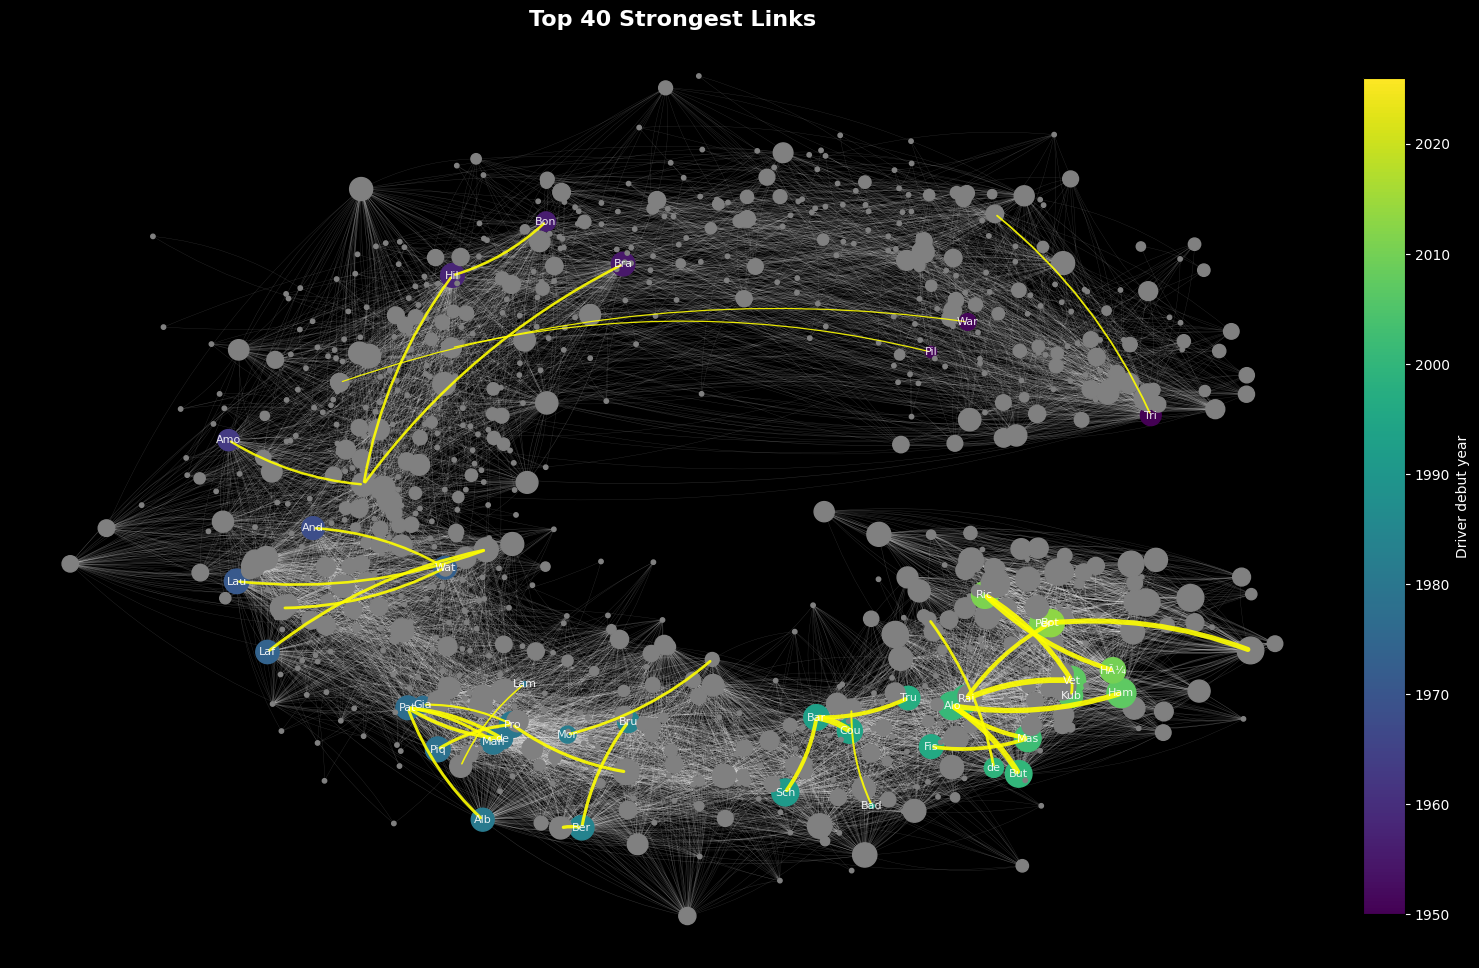

In [19]:

plt.figure(figsize=(18, 12))
ax = plt.gca()

ax.set_facecolor("black")
plt.gcf().set_facecolor("black")

strongest_edge_set = set((u, v) for (u, v, _) in strongest_edges.values())

for (u, v), w in zip(G.edges(), weights_norm):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    is_strong = (u, v) in strongest_edge_set

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        connectionstyle="arc3,rad=0.12",
        arrowstyle='-',
        linewidth=w * (1.5 if is_strong else 0.4),
        color=('yellow' if is_strong else "white"),
        alpha=(0.9 if is_strong else 0.2),
        zorder=(3 if is_strong else 1)
    )
    ax.add_patch(arrow)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=1.0
)

for n in top_nodes:
    x, y = pos[n]
    label = driver_code_map.get(n, str(n))

    plt.text(
        x,
        y,
        label,
        fontsize=8,
        color="white",
        ha="center",
        va="center",
        alpha=0.9
    )

plt.title(
    "Top 40 Strongest Links",
    color="white",
    fontweight='bold',
    fontsize=16
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  

cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Driver debut year", color="white")


cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')


plt.axis("off")
plt.show()



In [34]:
debut_year = r.groupby("driverId")["race_year"].min()
print(debut_year.unique())

[2007 2000 2006 2001 2008 2004 2002 1994 1997 1996 1993 2005 1991 1999
 2003 1989 1995 2009 1998 1992 1984 1987 1990 1988 1982 1980 1981 1977
 1985 1983 1986 1979 1978 1974 1975 1971 1973 1972 1968 1976 1970 1967
 1963 1958 1965 1964 1962 1960 1956 1969 1959 1955 1961 1966 1957 1950
 1951 1953 1952 1954 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024 2025 2026]


Figure 4. 

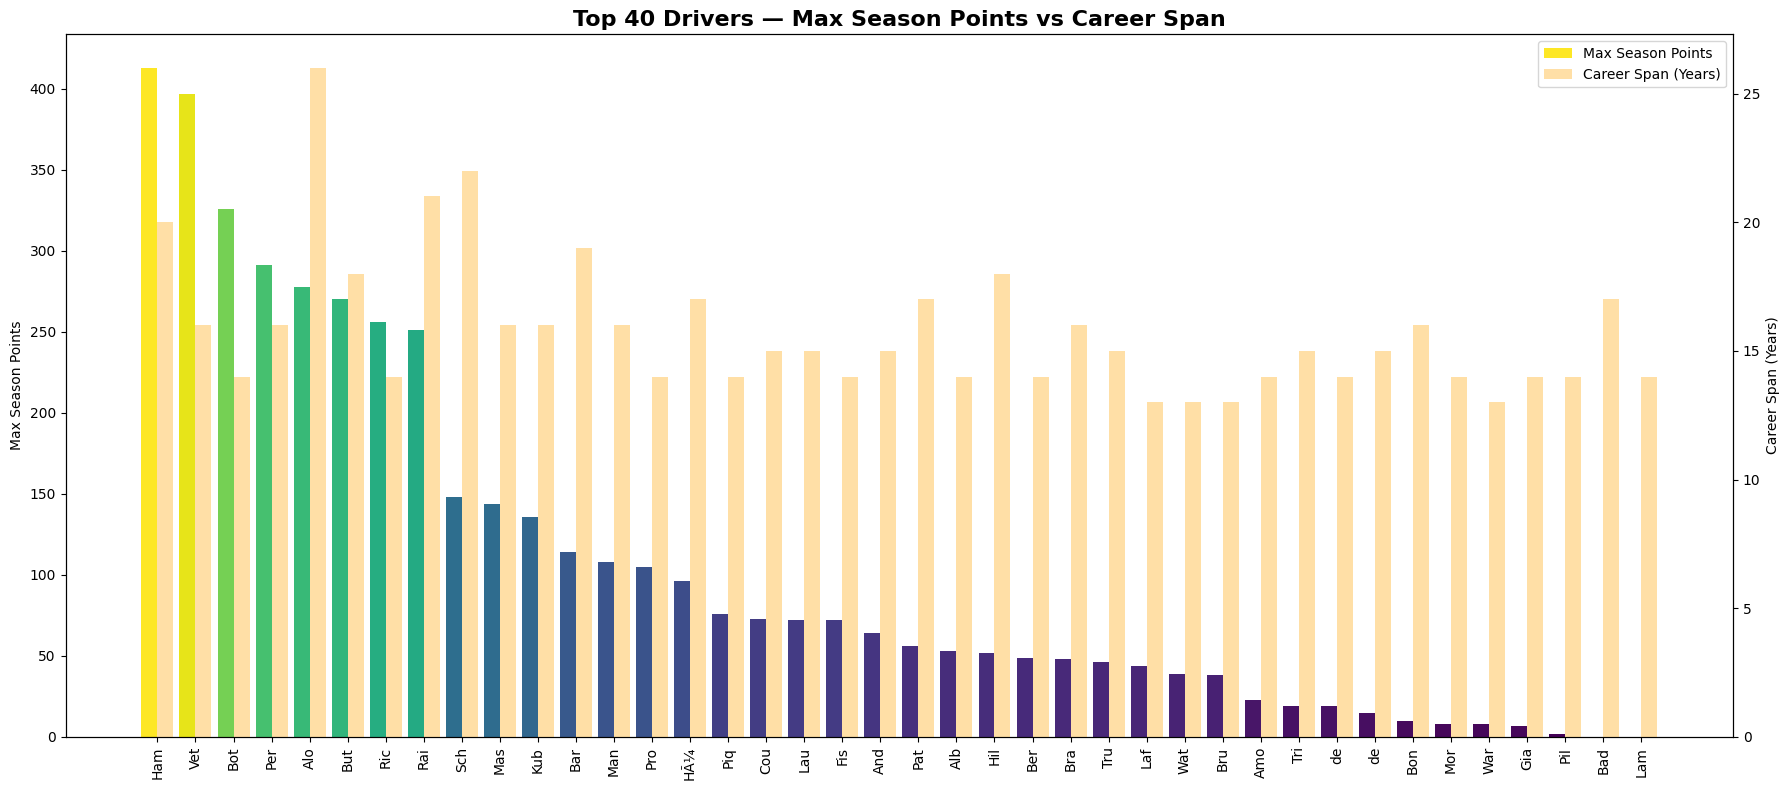

In [44]:
max_season_points = (
    season_points.groupby("driverId")["points"].max()
)

top_max_points = max_season_points.loc[top_nodes]

debut_year = r.groupby("driverId")["race_year"].min()

norm = colors.Normalize(
    vmin=top_max_points.min(),
    vmax=top_max_points.max()
)

df_plot = pd.DataFrame({
    "driverId": top_nodes,
    "driverCode": [driver_code_map.get(n, n) for n in top_nodes],
    "maxSeasonPoints": [max_season_points.get(n, 0) for n in top_nodes],
    "careerSpan": [career_span.loc[n, "span"] for n in top_nodes],
    "debutDecade": debut_year.loc[top_nodes] // 10 * 10,
 })


df_plot = df_plot.sort_values(
    "maxSeasonPoints",
    ascending=False
)

bar_colors = [
    cmap(norm(v))
    for v in df_plot["maxSeasonPoints"]
]

plt.figure(figsize=(18,8))

ax1 = plt.gca()
ax2 = ax1.twinx()

x = np.arange(len(df_plot))
width = 0.42


ax1.bar(
    x - width/2,
    df_plot["maxSeasonPoints"],
    width=width,
    color=bar_colors,
    label="Max Season Points"
)


ax2.bar(
    x + width/2,
    df_plot["careerSpan"],
    width=width,
    color="orange",
    alpha=0.35,
    label="Career Span (Years)"
)


ax1.set_xticks(x)
ax1.set_xticklabels(
    df_plot["driverCode"],
    rotation=90
)

ax1.set_ylabel("Max Season Points")
ax2.set_ylabel("Career Span (Years)")

plt.title(
    "Top 40 Drivers — Max Season Points vs Career Span",
    fontsize=16,
    fontweight="bold"
)


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right"
)

plt.tight_layout()
plt.show()

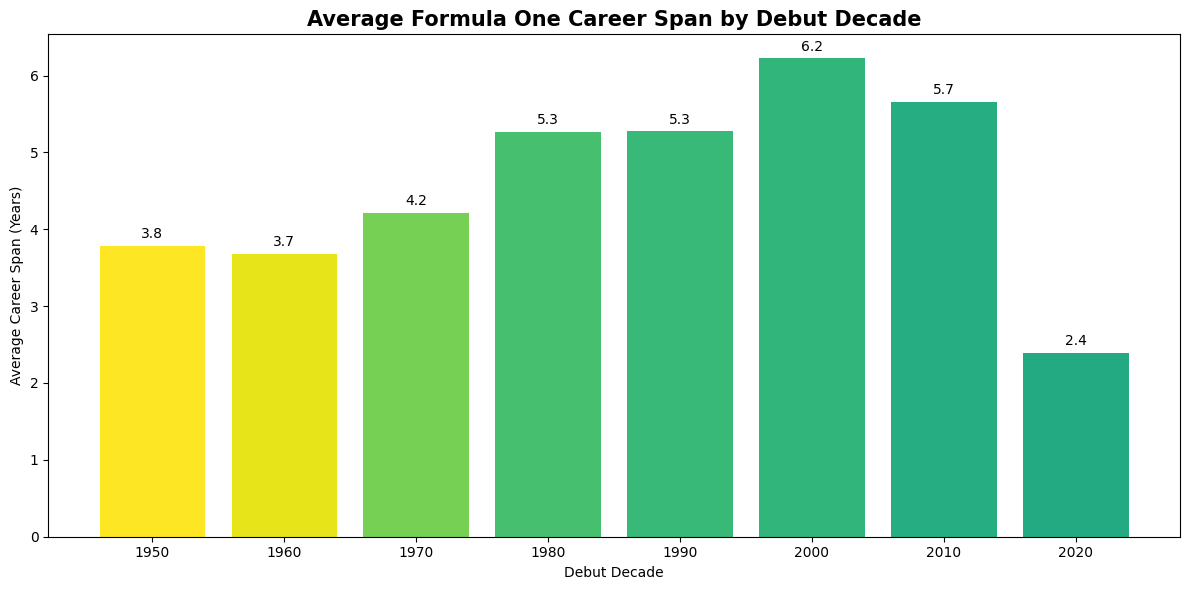

In [21]:

debut_year = r.groupby("driverId")["race_year"].min()


career_span = r.groupby("driverId")["race_year"].agg(["min", "max"])
career_span["span"] = career_span["max"] - career_span["min"] + 1


decade_df = pd.DataFrame({
    "debutYear": debut_year,
    "careerSpan": career_span["span"]
})


decade_df["debutDecade"] = (
    (decade_df["debutYear"] // 10) * 10
)

avg_span_by_decade = (
    decade_df
    .groupby("debutDecade")["careerSpan"]
    .mean()
    .sort_index()
)


plt.figure(figsize=(12,6))

x = avg_span_by_decade.index.astype(str)
y = avg_span_by_decade.values

bars = plt.bar(
    x,
    y,
    color=bar_colors
)


for i, v in enumerate(y):
    plt.text(
        i,
        v + 0.1,
        f"{v:.1f}",
        ha="center"
    )

plt.title(
    "Average Formula One Career Span by Debut Decade",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Debut Decade")
plt.ylabel("Average Career Span (Years)")

plt.tight_layout()
plt.show()

In [22]:
print(top_nodes)

[4, 30, 8, 1, 22, 18, 289, 807, 69, 119, 356, 9, 815, 347, 13, 95, 20, 427, 110, 15, 14, 182, 207, 37, 117, 90, 77, 136, 429, 105, 152, 817, 822, 278, 137, 21, 449, 187, 172, 84]


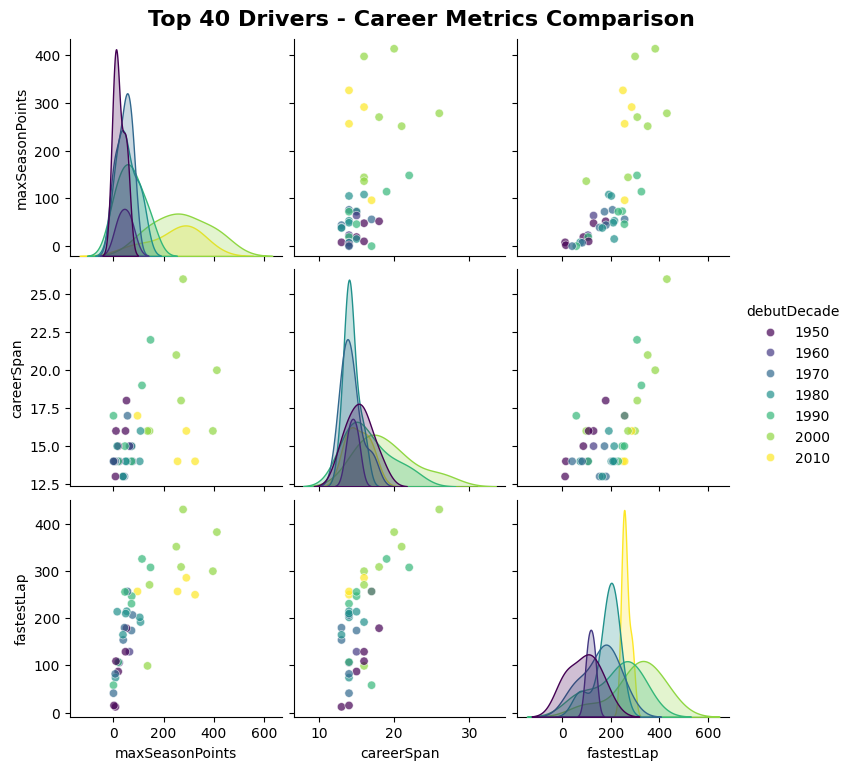

In [46]:
pp = pd.DataFrame({
    "driverId": top_nodes,
    "driverCode": [driver_code_map.get(n, n) for n in top_nodes],
    "maxSeasonPoints": [max_season_points.get(n, 0) for n in top_nodes],
    "careerSpan": [career_span.loc[n, "span"] for n in top_nodes],
    "debutDecade": debut_year.loc[top_nodes] // 10 * 10,
    "fastestLap": r.groupby("driverId")["fastestLap"].count().loc[top_nodes]

})


pp = pp.sort_values(
    "maxSeasonPoints",
    ascending=False
)
    

compare = pp[["maxSeasonPoints", "careerSpan", "fastestLap", "debutDecade"]]

lt = sns.pairplot(compare, hue = 'debutDecade', palette="viridis", diag_kind="kde", plot_kws={'alpha':0.7})
lt.fig.suptitle("Top 40 Drivers - Career Metrics Comparison", fontsize=16, fontweight='bold', y=1.02)
plt.show()